# 🔄 Telco Customer Churn Prediction — Full Pipeline
**End-to-end ML pipeline:** EDA → Preprocessing → Feature Engineering → DNN → XGBoost → LightGBM → Random Forest → Stacking Ensemble → SHAP

---
### Pipeline Overview
| Step | Description |
|------|-------------|
| 1 | Install & Import |
| 2 | Load Data + EDA |
| 3 | Preprocessing + Feature Engineering |
| 4 | Train/Val/Test Split + SMOTE |
| 5 | Deep Neural Network |
| 6 | Ensemble Models (XGB, LGB, RF, Stacking) |
| 7 | Unified Evaluation + Comparison |
| 8 | Threshold Tuning (on val set) |
| 9 | SHAP Explainability |


## 📦 Step 1: Install Dependencies

In [2]:
# Run once — comment out after first run
# !pip install tensorflow scikit-learn imbalanced-learn shap seaborn matplotlib pandas numpy xgboost lightgbm --quiet

## 📚 Step 2: Imports & Configuration

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")
np.random.seed(42)

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, RocCurveDisplay,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score,
)

# Models
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

import shap

tf.random.set_seed(42)

# Output directory
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ All libraries loaded")
print(f"TensorFlow: {tf.__version__}")

✅ All libraries loaded
TensorFlow: 2.20.0


## 📂 Step 3: Load Dataset
> Download from Kaggle: `WA_Fn-UseC_-Telco-Customer-Churn.csv`

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv") 

print(f"Shape: {df.shape}")
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df['Churn'].value_counts())
display(df.head())

Shape: (7043, 21)

Churn rate: 26.54%

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 📊 Step 4: Exploratory Data Analysis

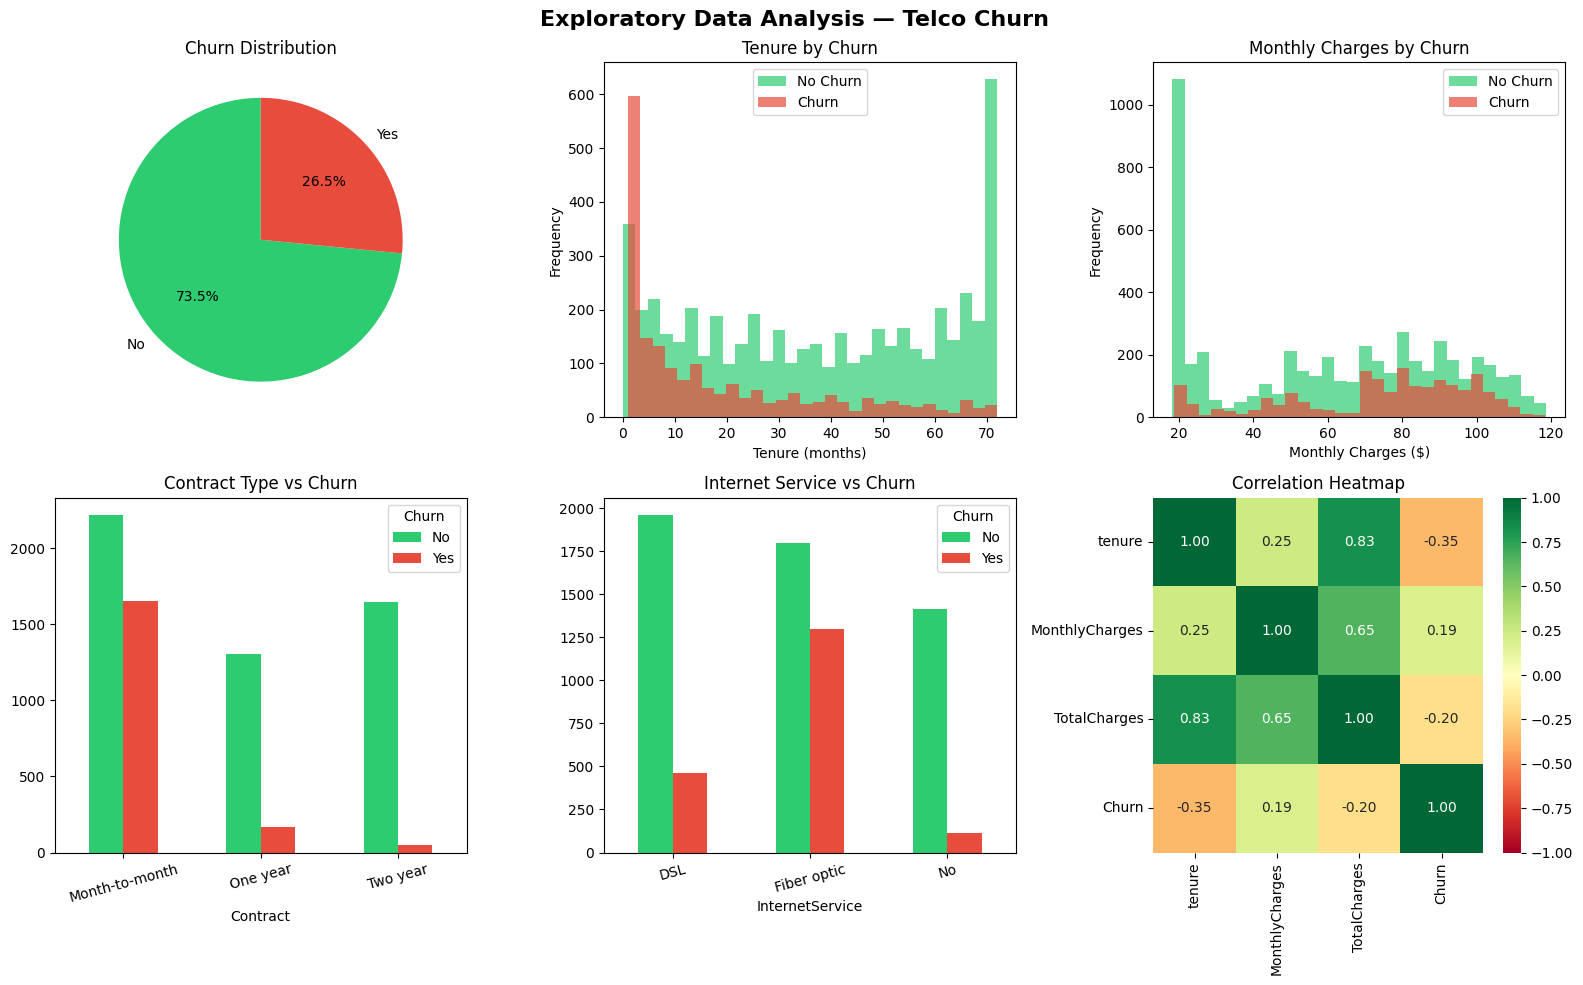

✅ EDA complete


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Exploratory Data Analysis — Telco Churn", fontsize=16, fontweight="bold")

# Churn pie
churn_counts = df["Churn"].value_counts()
axes[0, 0].pie(churn_counts, labels=churn_counts.index, autopct="%1.1f%%",
               colors=["#2ecc71", "#e74c3c"], startangle=90)
axes[0, 0].set_title("Churn Distribution")

# Tenure by churn
for label, color in zip(["No", "Yes"], ["#2ecc71", "#e74c3c"]):
    df[df["Churn"] == label]["tenure"].plot(
        kind="hist", ax=axes[0, 1], alpha=0.7, bins=30, color=color, label=label)
axes[0, 1].set_title("Tenure by Churn"); axes[0, 1].set_xlabel("Tenure (months)")
axes[0, 1].legend(["No Churn", "Churn"])

# Monthly charges
for label, color in zip(["No", "Yes"], ["#2ecc71", "#e74c3c"]):
    df[df["Churn"] == label]["MonthlyCharges"].plot(
        kind="hist", ax=axes[0, 2], alpha=0.7, bins=30, color=color)
axes[0, 2].set_title("Monthly Charges by Churn"); axes[0, 2].set_xlabel("Monthly Charges ($)")
axes[0, 2].legend(["No Churn", "Churn"])

# Contract vs Churn
df.groupby(["Contract", "Churn"]).size().unstack().plot(
    kind="bar", ax=axes[1, 0], color=["#2ecc71", "#e74c3c"], rot=15)
axes[1, 0].set_title("Contract Type vs Churn")

# Internet Service vs Churn
df.groupby(["InternetService", "Churn"]).size().unstack().plot(
    kind="bar", ax=axes[1, 1], color=["#2ecc71", "#e74c3c"], rot=15)
axes[1, 1].set_title("Internet Service vs Churn")

# Correlation heatmap
num_eda = df[["tenure", "MonthlyCharges", "TotalCharges"]].copy()
num_eda["TotalCharges"] = pd.to_numeric(num_eda["TotalCharges"], errors="coerce")
num_eda["Churn"] = (df["Churn"] == "Yes").astype(int)
sns.heatmap(num_eda.corr(), annot=True, fmt=".2f", cmap="RdYlGn",
            ax=axes[1, 2], vmin=-1, vmax=1)
axes[1, 2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA complete")

## 🔧 Step 5: Preprocessing + Feature Engineering

In [6]:
df_clean = df.copy()

# Fix TotalCharges blank strings
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
df_clean["TotalCharges"].fillna(df_clean["TotalCharges"].median(), inplace=True)

# Drop ID
df_clean.drop("customerID", axis=1, inplace=True)

# Encode target
df_clean["Churn"] = (df_clean["Churn"] == "Yes").astype(int)

# Binary Yes/No columns
binary_cols = [
    "Partner", "Dependents", "PhoneService", "PaperlessBilling",
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
]
for col in binary_cols:
    df_clean[col] = df_clean[col].map(
        {"Yes": 1, "No": 0, "No phone service": 0, "No internet service": 0}
    )

# Gender
df_clean["gender"] = (df_clean["gender"] == "Male").astype(int)

# One-hot encode multi-class categoricals
multi_cat_cols = ["InternetService", "Contract", "PaymentMethod"]
df_clean = pd.get_dummies(df_clean, columns=multi_cat_cols, drop_first=False)

# ── Feature Engineering ──────────────────────────────────────
df_clean["ChargesPerMonth"]   = df_clean["TotalCharges"] / (df_clean["tenure"] + 1)
df_clean["IsLongTenure"]      = (df_clean["tenure"] > 24).astype(int)
df_clean["HighMonthlyCharge"] = (
    df_clean["MonthlyCharges"] > df_clean["MonthlyCharges"].median()
).astype(int)

# Separate features and target
X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]
feature_names = X.columns.tolist()

# Scale numerical features
scaler = MinMaxScaler()
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "ChargesPerMonth"]
X[num_cols] = scaler.fit_transform(X[num_cols])

print(f"✅ Features after preprocessing: {X.shape[1]}")
print(f"Feature list: {feature_names}")
print(f"\nClass distribution:\n{y.value_counts()}")

✅ Features after preprocessing: 29
Feature list: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'ChargesPerMonth', 'IsLongTenure', 'HighMonthlyCharge']

Class distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


## ✂️ Step 6: Train / Val / Test Split + SMOTE
> SMOTE is applied **only** to the training set to prevent data leakage.

In [7]:
# 70% train | 15% val | 15% test  (all stratified)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.176,      # 0.176 × 0.85 ≈ 0.15 of total
    random_state=42, stratify=y_trainval,
)

# SMOTE on training set ONLY ✅
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

n_features = X_train_sm.shape[1]

print("✅ Split sizes:")
print(f"  Train (after SMOTE): {X_train_sm.shape[0]}")
print(f"  Validation         : {X_val.shape[0]}")
print(f"  Test               : {X_test.shape[0]}")
print(f"  Input features     : {n_features}")
print(f"\nTrain class balance after SMOTE:\n{pd.Series(y_train_sm).value_counts()}")

✅ Split sizes:
  Train (after SMOTE): 7246
  Validation         : 1054
  Test               : 1057
  Input features     : 29

Train class balance after SMOTE:
Churn
0    3623
1    3623
Name: count, dtype: int64


## 🧠 Step 7: Deep Neural Network
> Architecture: 256 → 128 → 64 → 32 → Sigmoid  
> BatchNorm + Dropout + L2 regularization

In [8]:
def build_dnn(n_features, lr=0.001, dropout=0.3, l2_reg=0.001):
    model = Sequential([
        Input(shape=(n_features,)),

        Dense(256, kernel_regularizer=l2(l2_reg)),
        BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        Dropout(dropout),

        Dense(128, kernel_regularizer=l2(l2_reg)),
        BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        Dropout(dropout),

        Dense(64, kernel_regularizer=l2(l2_reg)),
        BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        Dropout(dropout - 0.1),

        Dense(32, kernel_regularizer=l2(l2_reg)),
        BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        Dropout(0.1),

        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=Adam(lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return model


dnn_model = build_dnn(n_features)
dnn_model.summary()

callbacks_dnn = [
    EarlyStopping(monitor="val_loss", patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1),
    ModelCheckpoint(f"{OUTPUT_DIR}/best_dnn.keras",
                    monitor="val_auc", save_best_only=True,
                    mode="max", verbose=0),
]

history = dnn_model.fit(
    X_train_sm, y_train_sm,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=64,
    callbacks=callbacks_dnn,
    verbose=1,
)

print(f"\n✅ DNN done | Epochs: {len(history.history['loss'])}")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")
print(f"Best val_auc : {max(history.history['val_auc']):.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,865 (206.50 KB)

 Trainable params: 51,905 (202.75 KB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/150
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7306 - auc: 0.8028 - loss: 0.8858 - precision: 0.7179 - recall: 0.7599 - val_accuracy: 0.5787 - val_auc: 0.8194 - val_loss: 0.9884 - val_precision: 0.3794 - val_recall: 0.9214 - learning_rate: 0.0010
Epoch 2/150
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7693 - auc: 0.8459 - loss: 0.8013 - precision: 0.7433 - recall: 0.8225 - val_accuracy: 0.6063 - val_auc: 0.8215 - val_loss: 0.9565 - val_precision: 0.3950 - val_recall: 0.9071 - learning_rate: 0.0010
Epoch 3/150
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7813 - auc: 0.8569 - loss: 0.7580 - precision: 0.7559 - recall: 0.8308 - val_accuracy: 0.6793 - val_auc: 0.8193 - val_loss: 0.8797 - val_precision: 0.4475 - val_recall: 0.8821 - learning_rate: 0.0010
Epoch 4/150
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7882 - auc: 0.8682 - loss: 0.7140 - precision: 0.7676 - recall: 0.8267 - val_accuracy: 0.6964 - val_auc: 0.8199 - val_loss: 0.8341 

## 📉 Step 8: Training Curves + Overfitting Check

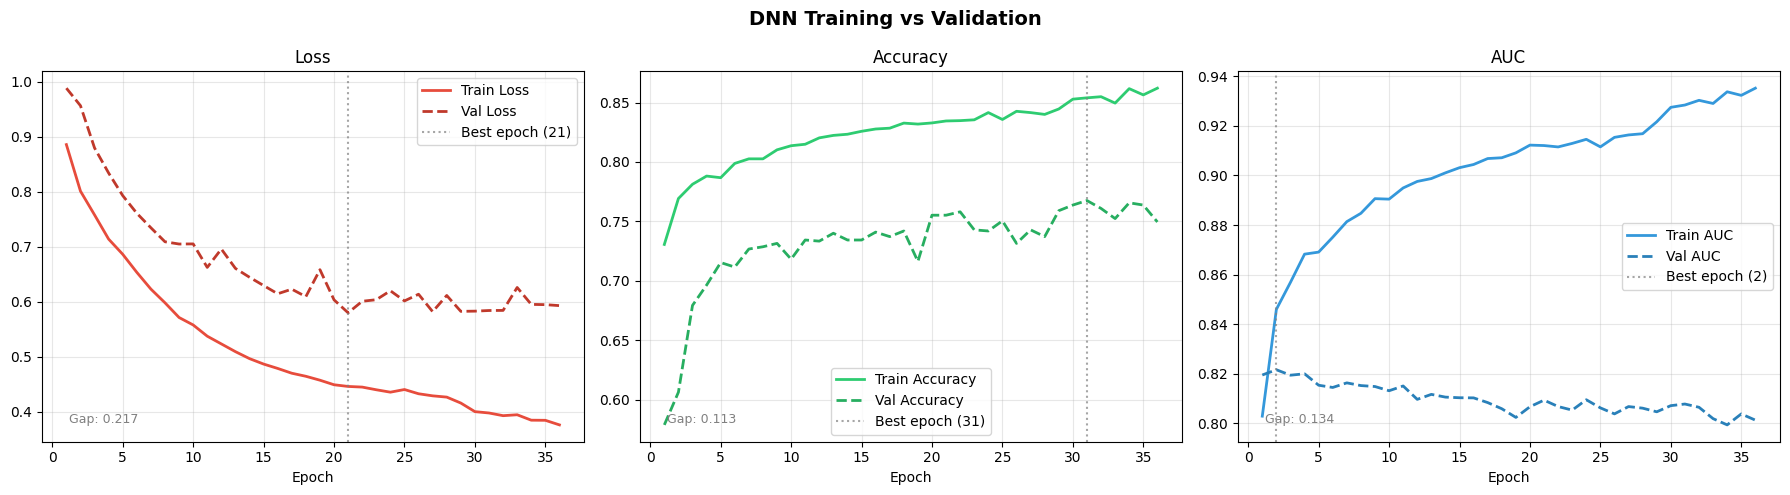

Train/Val accuracy gap: 0.1126  →  ❌ Overfitting


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("DNN Training vs Validation", fontsize=14, fontweight="bold")

for ax, metric, title, (tc, vc) in zip(
    axes,
    ["loss", "accuracy", "auc"],
    ["Loss", "Accuracy", "AUC"],
    [("#e74c3c","#c0392b"), ("#2ecc71","#27ae60"), ("#3498db","#2980b9")],
):
    tr = history.history[metric]
    va = history.history[f"val_{metric}"]
    ep = range(1, len(tr) + 1)
    ax.plot(ep, tr, color=tc, linewidth=2, label=f"Train {title}")
    ax.plot(ep, va, color=vc, linewidth=2, linestyle="--", label=f"Val {title}")
    best = np.argmin(va) + 1 if metric == "loss" else np.argmax(va) + 1
    ax.axvline(best, color="gray", linestyle=":", alpha=0.7, label=f"Best epoch ({best})")
    ax.annotate(f"Gap: {abs(tr[-1]-va[-1]):.3f}", xy=(0.05, 0.05),
                xycoords="axes fraction", fontsize=9, color="gray")
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

gap = history.history["accuracy"][-1] - history.history["val_accuracy"][-1]
status = "✅ No overfitting" if gap < 0.03 else ("⚠️ Mild overfitting" if gap < 0.07 else "❌ Overfitting")
print(f"Train/Val accuracy gap: {gap:.4f}  →  {status}")

## 🧪 Step 9: DNN Test Evaluation

  DNN — TEST SET RESULTS
  Accuracy    : 0.7625
  Precision   : 0.5399
  Recall      : 0.7000
  F1-Score    : 0.6096
  ROC-AUC     : 0.8078
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83       777
       Churn       0.54      0.70      0.61       280

    accuracy                           0.76      1057
   macro avg       0.71      0.74      0.72      1057
weighted avg       0.79      0.76      0.77      1057

💡 DNN optimal threshold (Youden's J): 0.474


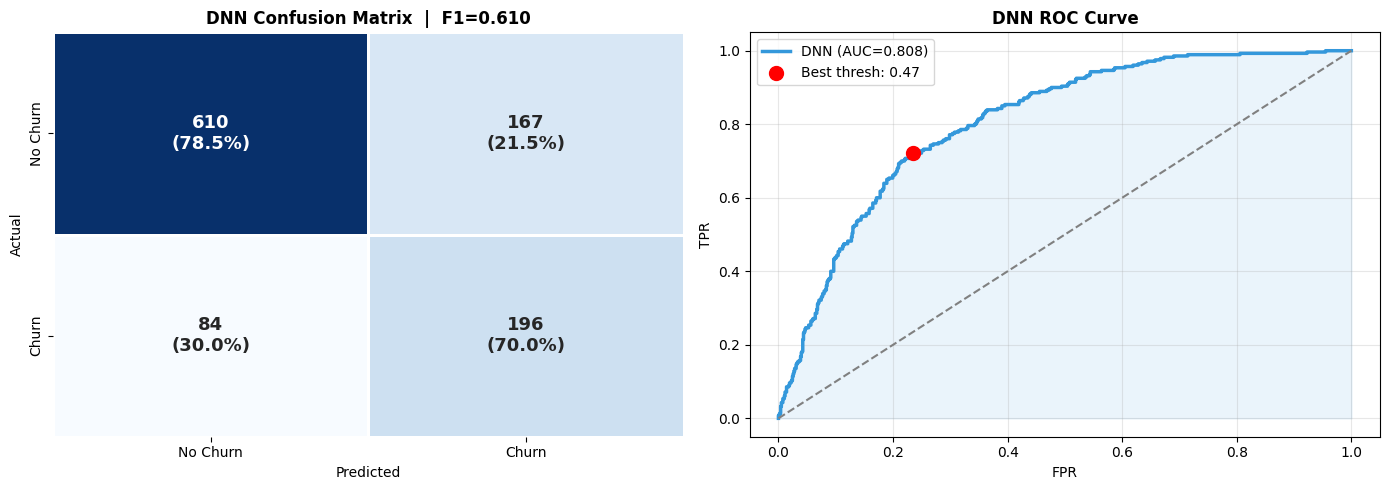

In [10]:
y_dnn_prob = dnn_model.predict(X_test, verbose=0).flatten()
y_dnn_pred = (y_dnn_prob >= 0.5).astype(int)

dnn_metrics = {
    "Accuracy" : accuracy_score(y_test, y_dnn_pred),
    "Precision": precision_score(y_test, y_dnn_pred),
    "Recall"   : recall_score(y_test, y_dnn_pred),
    "F1-Score" : f1_score(y_test, y_dnn_pred),
    "ROC-AUC"  : roc_auc_score(y_test, y_dnn_prob),
}
print("=" * 50)
print("  DNN — TEST SET RESULTS")
print("=" * 50)
for k, v in dnn_metrics.items():
    print(f"  {k:<12}: {v:.4f}")
print("=" * 50)
print(classification_report(y_test, y_dnn_pred, target_names=["No Churn", "Churn"]))

# Optimal threshold via Youden's J
fpr, tpr, thresholds = roc_curve(y_test, y_dnn_prob)
best_thresh_dnn = thresholds[np.argmax(tpr - fpr)]
print(f"💡 DNN optimal threshold (Youden's J): {best_thresh_dnn:.3f}")

# Confusion Matrix + ROC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_dnn_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
labels = np.array([[f"{v}\n({p:.1f}%)" for v, p in zip(rv, rp)]
                   for rv, rp in zip(cm, cm_pct)])
sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", ax=ax1,
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"],
            linewidths=2, linecolor="white", cbar=False,
            annot_kws={"size": 13, "weight": "bold"})
ax1.set_title(f"DNN Confusion Matrix  |  F1={dnn_metrics['F1-Score']:.3f}", fontweight="bold")
ax1.set_ylabel("Actual"); ax1.set_xlabel("Predicted")

ax2.plot(fpr, tpr, color="#3498db", linewidth=2.5,
         label=f"DNN (AUC={dnn_metrics['ROC-AUC']:.3f})")
ax2.plot([0, 1], [0, 1], "gray", linestyle="--")
best_idx = np.argmax(tpr - fpr)
ax2.scatter(fpr[best_idx], tpr[best_idx], color="red", s=100, zorder=5,
            label=f"Best thresh: {best_thresh_dnn:.2f}")
ax2.fill_between(fpr, tpr, alpha=0.1, color="#3498db")
ax2.set_title("DNN ROC Curve", fontweight="bold")
ax2.set_xlabel("FPR"); ax2.set_ylabel("TPR")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dnn_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## 🌲 Step 10: Ensemble Models
> All tree models trained on **original `X_train`** with `scale_pos_weight` / `class_weight`.  
> Early stopping uses **`X_val`** — NOT the test set.

In [11]:
# Class imbalance ratio
neg   = (y_train == 0).sum()
pos   = (y_train == 1).sum()
ratio = neg / pos
print(f"Class ratio (neg/pos) = {ratio:.2f}  |  pos={pos}, neg={neg}")

# ── XGBoost ──────────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    scale_pos_weight=ratio, eval_metric="auc",
    early_stopping_rounds=30, random_state=42, n_jobs=-1,
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],   # ✅ val set only
    verbose=50,
)
print(f"\n✅ XGBoost best iteration: {xgb_model.best_iteration}")

# ── LightGBM ─────────────────────────────────────────────────
lgb_model = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    num_leaves=31, min_child_samples=20, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    scale_pos_weight=ratio, random_state=42, n_jobs=-1, verbose=-1,
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],   # ✅ val set only
    eval_metric="auc",
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(50)],
)
print(f"\n✅ LightGBM best iteration: {lgb_model.best_iteration_}")

# ── Random Forest ─────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=5,
    min_samples_split=10, max_features="sqrt",
    class_weight="balanced", random_state=42, n_jobs=-1,
)
rf_model.fit(X_train, y_train)
print("\n✅ Random Forest trained")

# ── Stacking Ensemble ─────────────────────────────────────────
stacking_model = StackingClassifier(
    estimators=[
        ("xgb", xgb.XGBClassifier(
            n_estimators=xgb_model.best_iteration or 200,
            learning_rate=0.05, max_depth=5, subsample=0.8,
            colsample_bytree=0.8, scale_pos_weight=ratio,
            eval_metric="auc", random_state=42, n_jobs=-1)),
        ("lgb", lgb.LGBMClassifier(
            n_estimators=lgb_model.best_iteration_ or 200,
            learning_rate=0.05, num_leaves=31,
            scale_pos_weight=ratio, random_state=42, n_jobs=-1, verbose=-1)),
        ("rf", RandomForestClassifier(
            n_estimators=300, max_depth=10, class_weight="balanced",
            random_state=42, n_jobs=-1)),
    ],
    final_estimator=LogisticRegression(
        C=1.0, class_weight="balanced", max_iter=1000, random_state=42),
    cv=5, stack_method="predict_proba", n_jobs=-1,
)
stacking_model.fit(X_train, y_train)
print("\n✅ Stacking Ensemble trained")

Class ratio (neg/pos) = 2.77  |  pos=1309, neg=3623
[0]	validation_0-auc:0.81638
[50]	validation_0-auc:0.83400
[98]	validation_0-auc:0.83425

✅ XGBoost best iteration: 68
[50]	valid_0's auc: 0.831439	valid_0's binary_logloss: 0.478332

✅ LightGBM best iteration: 26

✅ Random Forest trained

✅ Stacking Ensemble trained


## 📋 Step 11: Unified Evaluation — All Models

In [12]:
def evaluate_model(name, model, X, y, threshold=0.5, is_keras=False):
    proba = model.predict(X, verbose=0).flatten() if is_keras else model.predict_proba(X)[:, 1]
    preds = (proba >= threshold).astype(int)
    return {
        "Model"    : name,
        "Accuracy" : accuracy_score(y, preds),
        "Precision": precision_score(y, preds),
        "Recall"   : recall_score(y, preds),
        "F1-Score" : f1_score(y, preds),
        "ROC-AUC"  : roc_auc_score(y, proba),
        "PR-AUC"   : average_precision_score(y, proba),
        "proba"    : proba,
    }


models_eval = {
    "DNN"              : (dnn_model,      True),
    "XGBoost"          : (xgb_model,      False),
    "LightGBM"         : (lgb_model,      False),
    "Random Forest"    : (rf_model,       False),
    "Stacking Ensemble": (stacking_model, False),
}

results = {}
for name, (model, is_keras) in models_eval.items():
    results[name] = evaluate_model(name, model, X_test, y_test, is_keras=is_keras)
    r = results[name]
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {r['Accuracy']:.4f}  |  Precision: {r['Precision']:.4f}")
    print(f"  Recall   : {r['Recall']:.4f}  |  F1-Score : {r['F1-Score']:.4f}")
    print(f"  ROC-AUC  : {r['ROC-AUC']:.4f}  |  PR-AUC   : {r['PR-AUC']:.4f}")


  DNN
  Accuracy : 0.7625  |  Precision: 0.5399
  Recall   : 0.7000  |  F1-Score : 0.6096
  ROC-AUC  : 0.8078  |  PR-AUC   : 0.5583

  XGBoost
  Accuracy : 0.7569  |  Precision: 0.5264
  Recall   : 0.8179  |  F1-Score : 0.6406
  ROC-AUC  : 0.8507  |  PR-AUC   : 0.6601

  LightGBM
  Accuracy : 0.7871  |  Precision: 0.5758
  Recall   : 0.7464  |  F1-Score : 0.6501
  ROC-AUC  : 0.8480  |  PR-AUC   : 0.6535

  Random Forest
  Accuracy : 0.7767  |  Precision: 0.5561
  Recall   : 0.7786  |  F1-Score : 0.6488
  ROC-AUC  : 0.8506  |  PR-AUC   : 0.6593

  Stacking Ensemble
  Accuracy : 0.7597  |  Precision: 0.5304
  Recall   : 0.8107  |  F1-Score : 0.6412
  ROC-AUC  : 0.8505  |  PR-AUC   : 0.6604


## 🏆 Step 12: Model Comparison Table

In [13]:
summary_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "proba"}
    for r in results.values()
]).set_index("Model").round(4)

display(summary_df.sort_values("ROC-AUC", ascending=False))

best_model_name = summary_df["ROC-AUC"].idxmax()
print(f"\n🏆 Best model by ROC-AUC: {best_model_name} ({summary_df.loc[best_model_name,'ROC-AUC']:.4f})")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
XGBoost,0.7569,0.5264,0.8179,0.6406,0.8507,0.6601
Random Forest,0.7767,0.5561,0.7786,0.6488,0.8506,0.6593
Stacking Ensemble,0.7597,0.5304,0.8107,0.6412,0.8505,0.6604
LightGBM,0.7871,0.5758,0.7464,0.6501,0.8480,0.6535
DNN,0.7625,0.5399,0.7000,0.6096,0.8078,0.5583



🏆 Best model by ROC-AUC: XGBoost (0.8507)


## 📊 Step 13: Ensemble Comparison Visualizations

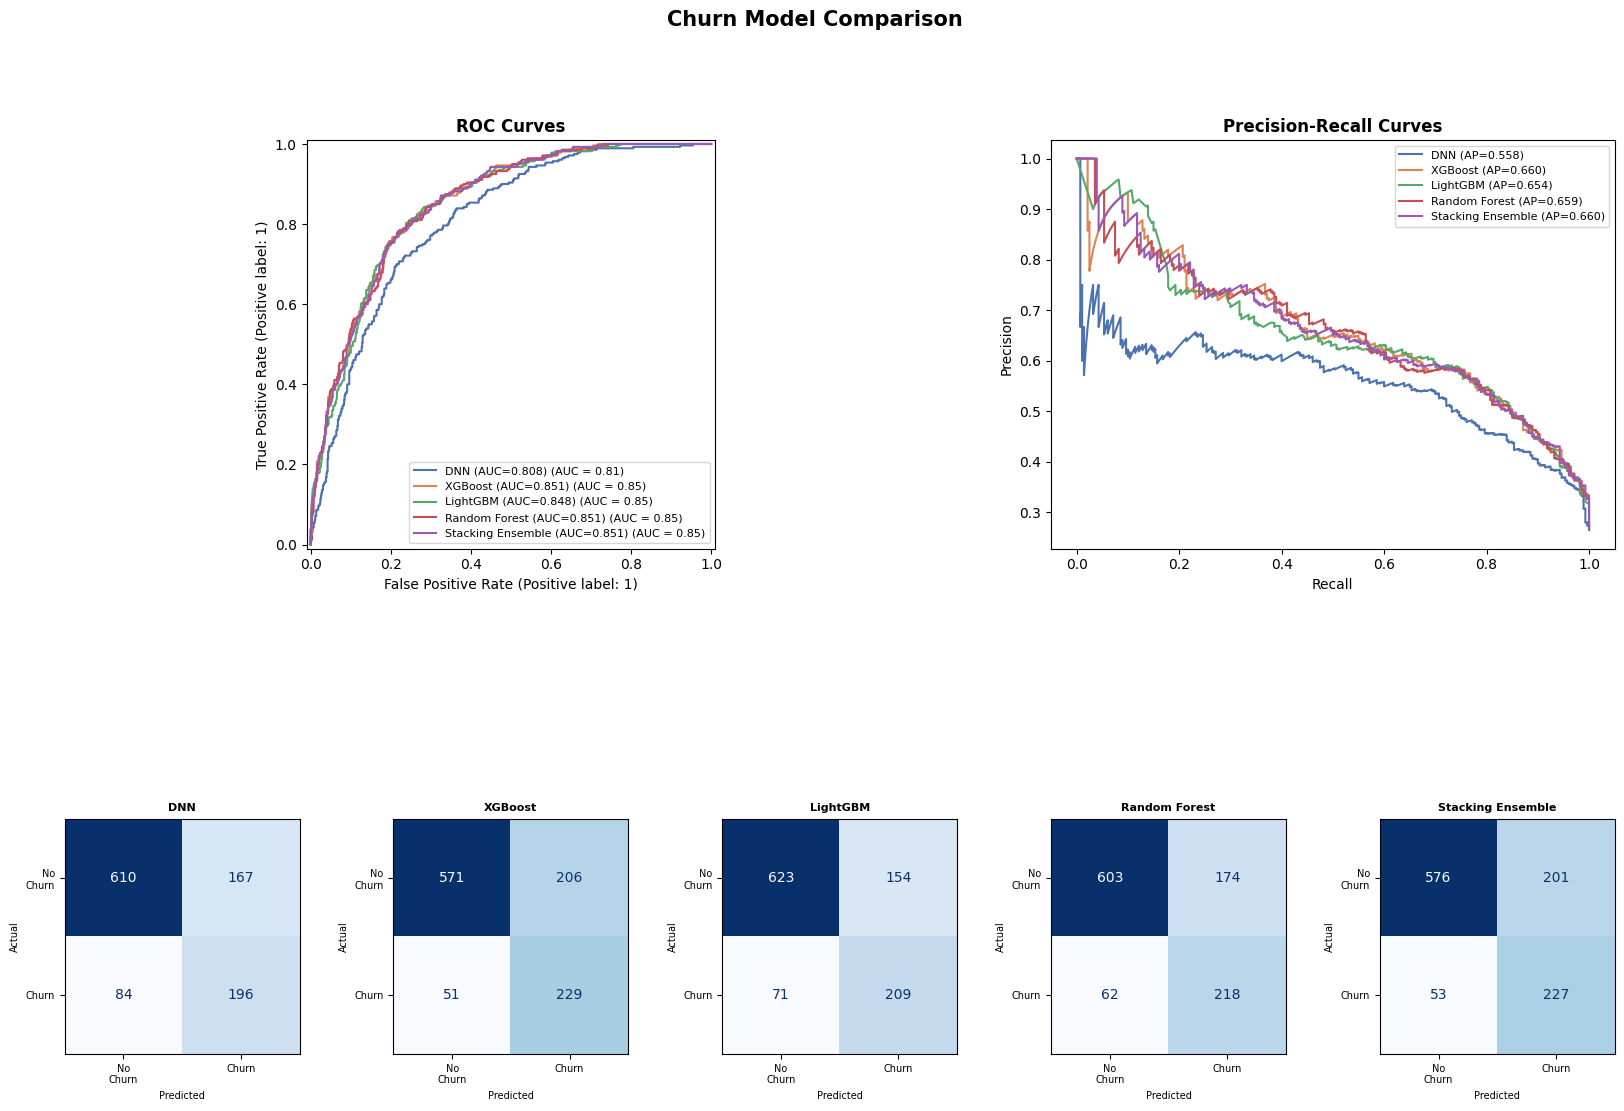

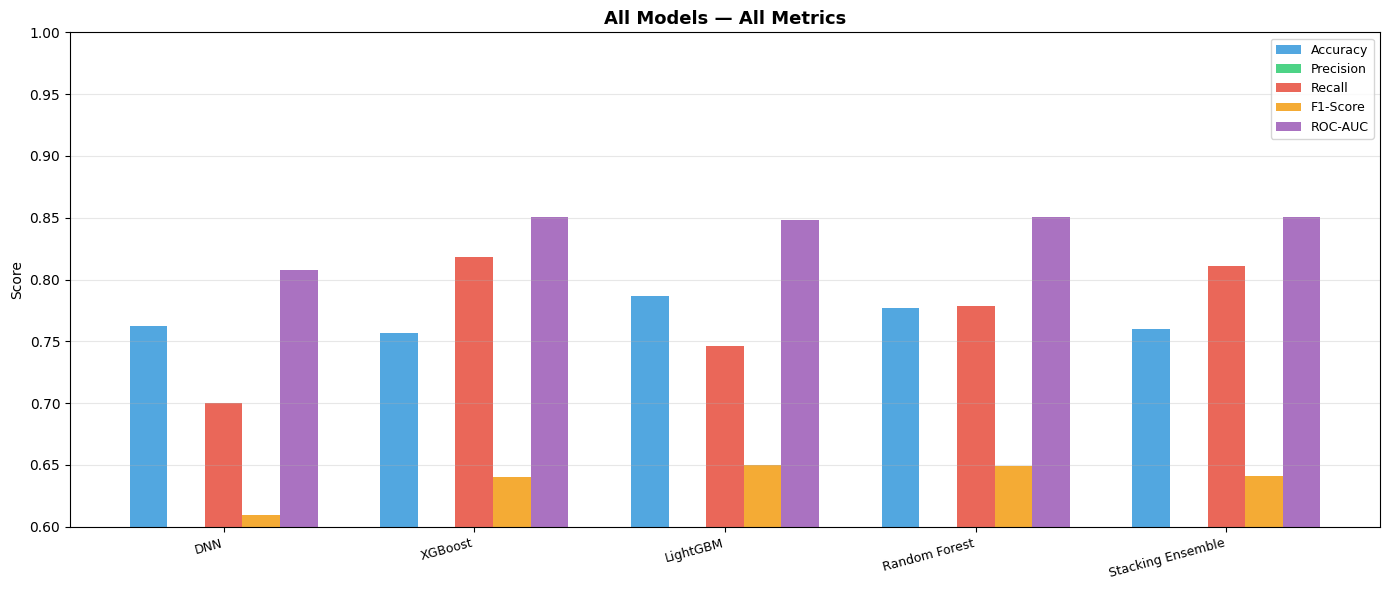

In [14]:
# ── ROC + PR + Confusion Matrices ────────────────────────────
fig = plt.figure(figsize=(20, 13))
fig.suptitle("Churn Model Comparison", fontsize=15, fontweight="bold")
gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.45, wspace=0.4)
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#9B59B6"]

ax_roc = fig.add_subplot(gs[0, :3])
for (name, res), col in zip(results.items(), colors):
    RocCurveDisplay.from_predictions(y_test, res["proba"],
        name=f"{name} (AUC={res['ROC-AUC']:.3f})", ax=ax_roc, color=col)
ax_roc.set_title("ROC Curves", fontweight="bold"); ax_roc.legend(fontsize=8)

ax_pr = fig.add_subplot(gs[0, 3:])
for (name, res), col in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res["proba"])
    ax_pr.plot(rec, prec, label=f"{name} (AP={res['PR-AUC']:.3f})", color=col)
ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall Curves", fontweight="bold"); ax_pr.legend(fontsize=8)

for idx, (name, _) in enumerate(models_eval.items()):
    ax = fig.add_subplot(gs[1, idx])
    cm = confusion_matrix(y_test, (results[name]["proba"] >= 0.5).astype(int))
    ConfusionMatrixDisplay(cm, display_labels=["No\nChurn","Churn"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=8, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=7); ax.set_ylabel("Actual", fontsize=7)
    ax.tick_params(labelsize=7)

plt.savefig(f"{OUTPUT_DIR}/ensemble_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Metric Bar Chart ──────────────────────────────────────────
metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
bar_colors  = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12", "#9b59b6"]
x = np.arange(len(summary_df)); width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metric_cols, bar_colors)):
    ax.bar(x + i*width, summary_df.loc[list(results.keys()), metric],
           width, label=metric, color=color, alpha=0.85)
ax.set_xticks(x + 2*width)
ax.set_xticklabels(list(results.keys()), rotation=15, ha="right", fontsize=9)
ax.set_ylim(0.6, 1.0); ax.set_ylabel("Score")
ax.set_title("All Models — All Metrics", fontsize=13, fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/metric_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## 🔍 Step 14: Feature Importance (XGBoost & LightGBM)

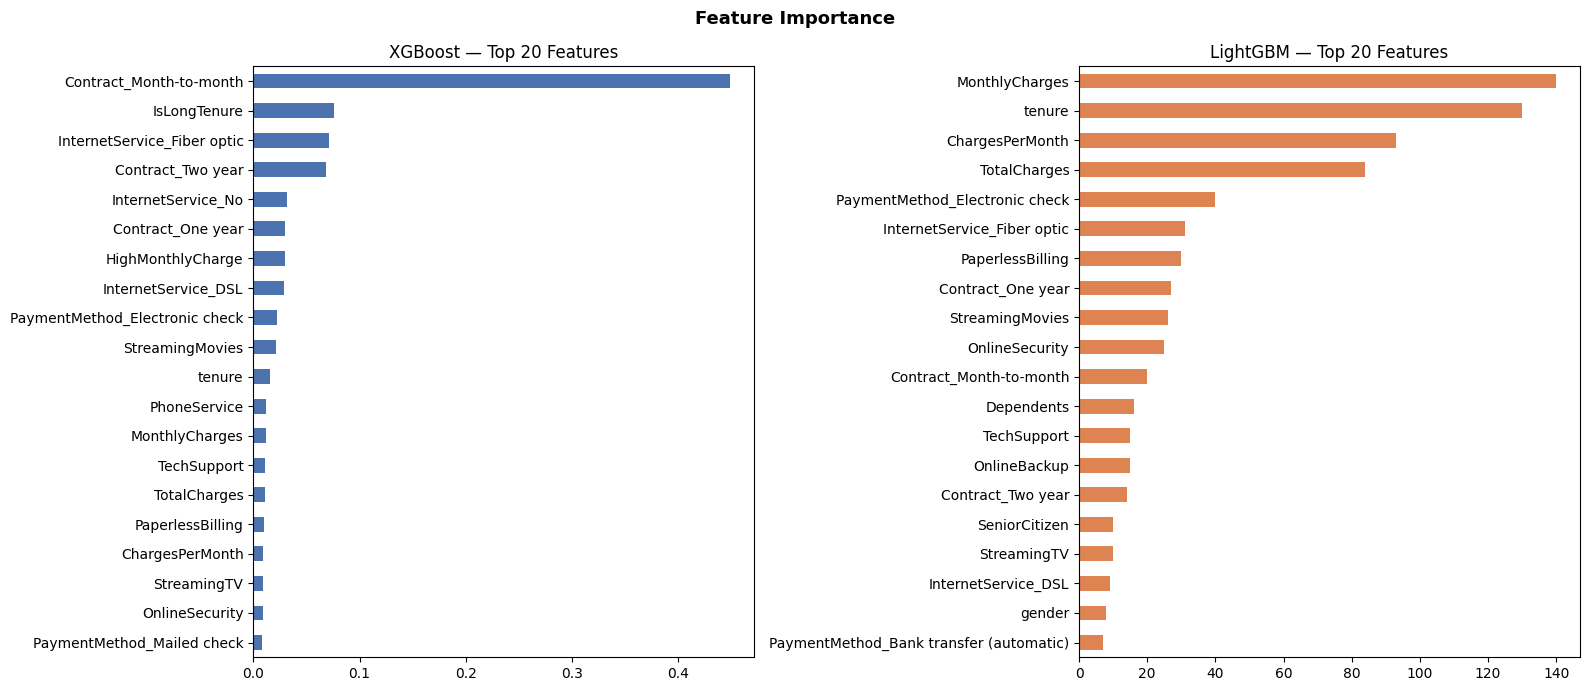

In [15]:
feat_index = X_train.columns if hasattr(X_train, "columns") else feature_names

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Feature Importance", fontsize=13, fontweight="bold")

pd.Series(xgb_model.feature_importances_, index=feat_index)  .sort_values().tail(20).plot.barh(ax=ax1, color="#4C72B0")
ax1.set_title("XGBoost — Top 20 Features")

pd.Series(lgb_model.feature_importances_, index=feat_index)  .sort_values().tail(20).plot.barh(ax=ax2, color="#DD8452")
ax2.set_title("LightGBM — Top 20 Features")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 🎯 Step 15: Threshold Tuning
> Tune threshold on **validation set**, then apply to **test set** only once.

In [16]:
best_model_obj, best_is_keras = models_eval[best_model_name]

# Get val probabilities for tuning
val_proba = (best_model_obj.predict(X_val, verbose=0).flatten() if best_is_keras
             else best_model_obj.predict_proba(X_val)[:, 1])

best_t, best_f1_val = 0.5, 0.0
for t in np.arange(0.2, 0.71, 0.01):
    f1 = f1_score(y_val, (val_proba >= t).astype(int))
    if f1 > best_f1_val:
        best_f1_val, best_t = f1, t

print(f"Best threshold (val): {best_t:.2f}  |  Best F1 (val): {best_f1_val:.4f}")

# Apply best threshold to test set (only once)
result_tuned = evaluate_model(
    f"{best_model_name} @ thresh={best_t:.2f}",
    best_model_obj, X_test, y_test,
    threshold=best_t, is_keras=best_is_keras
)
print(f"\nTest F1    (thresh={best_t:.2f}): {result_tuned['F1-Score']:.4f}")
print(f"Test Recall               : {result_tuned['Recall']:.4f}")
print(f"Test AUC                  : {result_tuned['ROC-AUC']:.4f}")
print("\n" + classification_report(
    y_test, (result_tuned["proba"] >= best_t).astype(int),
    target_names=["No Churn", "Churn"]
))

Best threshold (val): 0.52  |  Best F1 (val): 0.6300

Test F1    (thresh=0.52): 0.6409
Test Recall               : 0.8000
Test AUC                  : 0.8507

              precision    recall  f1-score   support

    No Churn       0.91      0.75      0.82       777
       Churn       0.53      0.80      0.64       280

    accuracy                           0.76      1057
   macro avg       0.72      0.77      0.73      1057
weighted avg       0.81      0.76      0.77      1057



## 🔬 Step 16: SHAP Explainability
> Uses `TreeExplainer` for tree models (fast) and `KernelExplainer` for DNN.

⏳ Computing SHAP values...


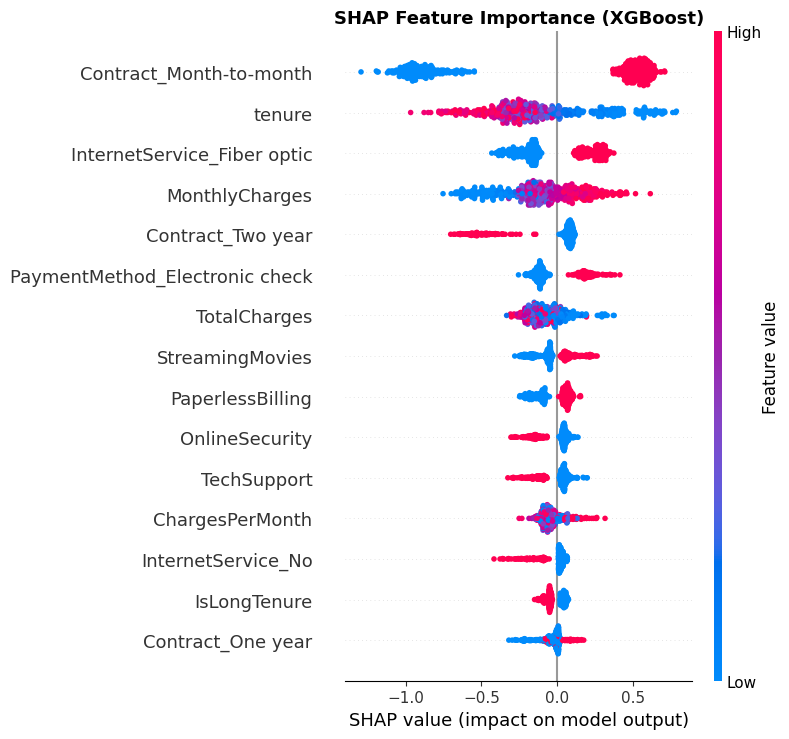

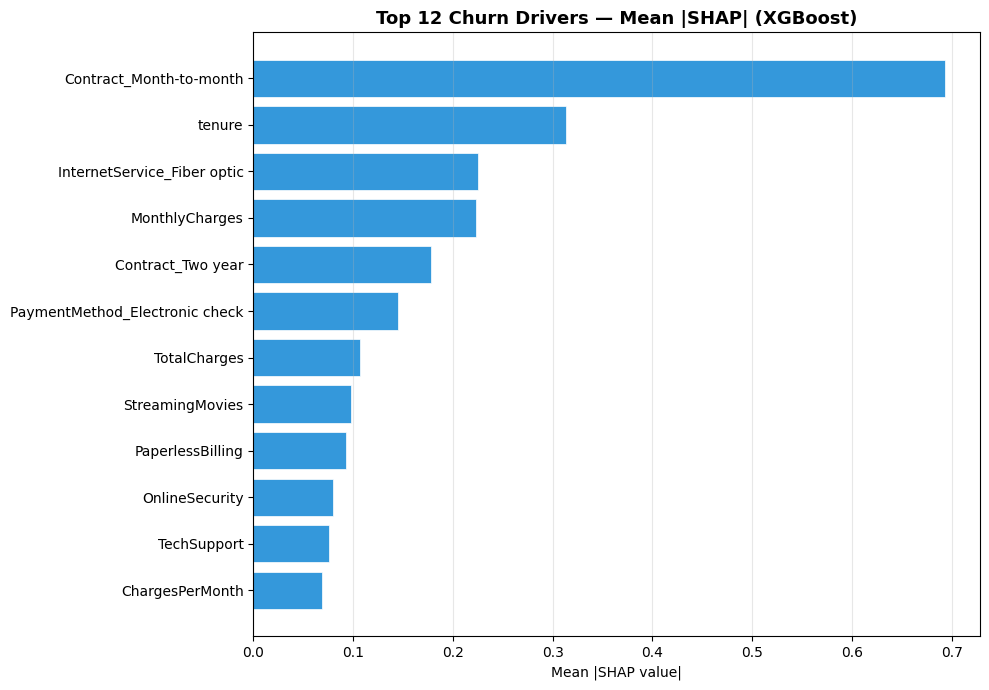

✅ SHAP analysis complete!


In [17]:
print("⏳ Computing SHAP values...")

if "LightGBM" in best_model_name or "XGBoost" in best_model_name:
    # Fast TreeExplainer
    explainer  = shap.TreeExplainer(best_model_obj)
    X_test_arr = X_test.values if hasattr(X_test, "values") else X_test
    shap_values= explainer.shap_values(X_test_arr[:500])
    shap_vals  = shap_values[1] if isinstance(shap_values, list) else shap_values
else:
    # KernelExplainer for DNN
    background    = X_train_sm[:200].astype(np.float32)
    X_test_arr    = X_test.iloc[:200].values.astype(np.float32)
    explainer     = shap.KernelExplainer(
        lambda x: best_model_obj.predict(x.astype(np.float32), verbose=0),
        background,
    )
    shap_values   = explainer.shap_values(X_test_arr, nsamples=100)
    shap_vals     = shap_values[0] if isinstance(shap_values, list) else shap_values

# Summary dot plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_test_arr[:500], feature_names=feature_names,
                  max_display=15, plot_type="dot", show=False)
plt.title(f"SHAP Feature Importance ({best_model_name})", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar plot
mean_shap = np.abs(shap_vals).mean(axis=0).flatten()
shap_df = (pd.DataFrame({"feature": feature_names, "importance": mean_shap})
             .sort_values("importance").tail(12))
plt.figure(figsize=(10, 7))
plt.barh(shap_df["feature"], shap_df["importance"],
         color="#3498db", edgecolor="white", linewidth=0.5)
plt.title(f"Top 12 Churn Drivers — Mean |SHAP| ({best_model_name})",
          fontsize=13, fontweight="bold")
plt.xlabel("Mean |SHAP value|")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ SHAP analysis complete!")

## ✅ Step 17: Final Summary

In [18]:
print("=" * 70)
print("  FINAL MODEL COMPARISON — sorted by ROC-AUC")
print("=" * 70)
display(summary_df.sort_values("ROC-AUC", ascending=False))

print(f"\n🏆 Best model        : {best_model_name}")
print(f"   Best ROC-AUC      : {summary_df['ROC-AUC'].max():.4f}")
print(f"   Optimal threshold : {best_t:.2f}  (tuned on validation set)")
print(f"\n📁 Outputs saved to: ./{OUTPUT_DIR}/")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"   └── {f}")

  FINAL MODEL COMPARISON — sorted by ROC-AUC


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
XGBoost,0.7569,0.5264,0.8179,0.6406,0.8507,0.6601
Random Forest,0.7767,0.5561,0.7786,0.6488,0.8506,0.6593
Stacking Ensemble,0.7597,0.5304,0.8107,0.6412,0.8505,0.6604
LightGBM,0.7871,0.5758,0.7464,0.6501,0.8480,0.6535
DNN,0.7625,0.5399,0.7000,0.6096,0.8078,0.5583



🏆 Best model        : XGBoost
   Best ROC-AUC      : 0.8507
   Optimal threshold : 0.52  (tuned on validation set)

📁 Outputs saved to: ./outputs/
   └── best_dnn.keras
   └── dnn_evaluation.png
   └── eda_plots.png
   └── ensemble_comparison.png
   └── feature_importance.png
   └── metric_bar_chart.png
   └── shap_bar.png
   └── shap_summary.png
   └── training_curves.png


In [19]:
# ============================================================
#  STEP 1 — Save All Models & Artifacts After Training
#  Run this at the END of your churn_pipeline notebook
# ============================================================

import os
import pickle
import json
import numpy as np
import pandas as pd
import joblib

SAVE_DIR = "saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 1. Save LightGBM ────────────────────────────────────────
lgb_model.booster_.save_model(f"{SAVE_DIR}/lgb_model.txt")
print("✅ LightGBM saved → saved_models/lgb_model.txt")

# ── 2. Save XGBoost ─────────────────────────────────────────
xgb_model.save_model(f"{SAVE_DIR}/xgb_model.json")
print("✅ XGBoost saved → saved_models/xgb_model.json")

# ── 3. Save DNN (Keras) ──────────────────────────────────────
dnn_model.save(f"{SAVE_DIR}/dnn_model.keras")
print("✅ DNN saved → saved_models/dnn_model.keras")

# ── 4. Save Scaler ───────────────────────────────────────────
joblib.dump(scaler, f"{SAVE_DIR}/scaler.pkl")
print("✅ Scaler saved → saved_models/scaler.pkl")

# ── 5. Save Feature Names & Metadata ────────────────────────
metadata = {
    "feature_names": feature_names,
    "num_cols": ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "ChargesPerMonth"],
    "best_threshold": float(best_t),
    "lgb_weight": 0.55,
    "dnn_weight": 0.45,
    "model_auc": {
        "lgb": float(summary_df.loc["LightGBM", "ROC-AUC"]),
        "dnn": float(summary_df.loc["DNN", "ROC-AUC"]),
        "ensemble": float((summary_df.loc["LightGBM", "ROC-AUC"] * 0.55
                           + summary_df.loc["DNN", "ROC-AUC"] * 0.45)),
    },
    "binary_cols": [
        "Partner", "Dependents", "PhoneService", "PaperlessBilling",
        "MultipleLines", "OnlineSecurity", "OnlineBackup",
        "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    ],
    "multi_cat_cols": ["InternetService", "Contract", "PaymentMethod"],
}
with open(f"{SAVE_DIR}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("✅ Metadata saved → saved_models/metadata.json")

# ── 6. Save SHAP Explainer (LightGBM) ───────────────────────
import shap
lgb_explainer = shap.TreeExplainer(lgb_model)
joblib.dump(lgb_explainer, f"{SAVE_DIR}/lgb_shap_explainer.pkl")
print("✅ SHAP explainer saved → saved_models/lgb_shap_explainer.pkl")

# ── 7. Quick sanity check ────────────────────────────────────
print("\n" + "="*50)
print("  SANITY CHECK — reload & predict one sample")
print("="*50)

import lightgbm as lgb_lib
import xgboost as xgb_lib
from tensorflow import keras

lgb_reload  = lgb_lib.Booster(model_file=f"{SAVE_DIR}/lgb_model.txt")
dnn_reload  = keras.models.load_model(f"{SAVE_DIR}/dnn_model.keras")
scaler_rel  = joblib.load(f"{SAVE_DIR}/scaler.pkl")

sample = X_test.iloc[[0]]
lgb_p  = lgb_reload.predict(sample)[0]
dnn_p  = dnn_reload.predict(sample, verbose=0)[0][0]
ens_p  = lgb_p * 0.55 + dnn_p * 0.45

print(f"  Sample churn probabilities:")
print(f"  LightGBM : {lgb_p:.4f}")
print(f"  DNN      : {dnn_p:.4f}")
print(f"  Ensemble : {ens_p:.4f}")
print(f"  Actual   : {y_test.iloc[0]}")
print("\n✅ All models verified & ready for deployment!")

# ── 8. Print file sizes ──────────────────────────────────────
print("\n  Saved files:")
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f"{SAVE_DIR}/{f}")
    print(f"  └── {f:<35} {size/1024:.1f} KB")


✅ LightGBM saved → saved_models/lgb_model.txt
✅ XGBoost saved → saved_models/xgb_model.json
✅ DNN saved → saved_models/dnn_model.keras
✅ Scaler saved → saved_models/scaler.pkl
✅ Metadata saved → saved_models/metadata.json
✅ SHAP explainer saved → saved_models/lgb_shap_explainer.pkl

  SANITY CHECK — reload & predict one sample
  Sample churn probabilities:
  LightGBM : 0.1336
  DNN      : 0.1594
  Ensemble : 0.1452
  Actual   : 0

✅ All models verified & ready for deployment!

  Saved files:
  └── dnn_model.keras                     687.8 KB
  └── lgb_model.txt                       91.8 KB
  └── lgb_shap_explainer.pkl              244.0 KB
  └── metadata.json                       1.4 KB
  └── scaler.pkl                          1.2 KB
  └── xgb_model.json                      316.5 KB
